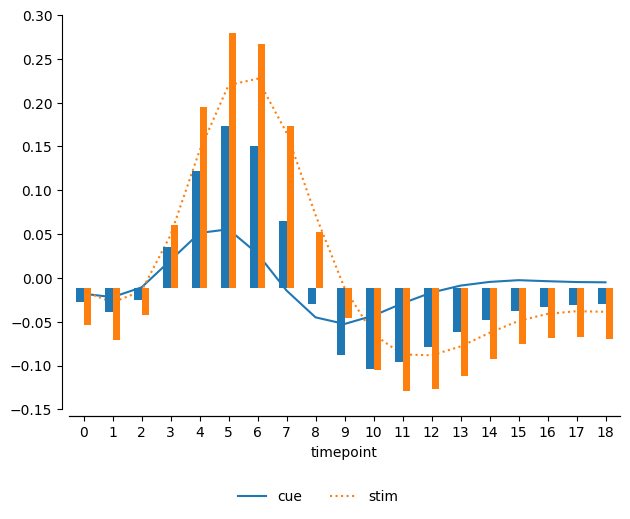

In [11]:
import numpy as np
import pandas as pd
import pytae as pt

fmri = pt.sample_data['fmri']

t = pt.Plotter() #if no mosaic is plotted it will automatically work on single subplot
(t
.data(fmri)
.plot(x='timepoint', y='signal',by='event',aggfunc='mean',
      kind='line',style={'cue':'-','stim':':'},ylim=(-0.15,0.3),print_data=0)
.plot(x='timepoint', y='signal',by='region',kind='bar',stacked=False,aggfunc='mean',on='A^',legend=False,print_data=0) 
.finalize(consolidate_legends=True, bbox_to_anchor=(0.65, -0.005), hide_secondary_y=True)
)
t.fig

In [14]:
print(pt.sample_data.keys())

dict_keys(['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic'])


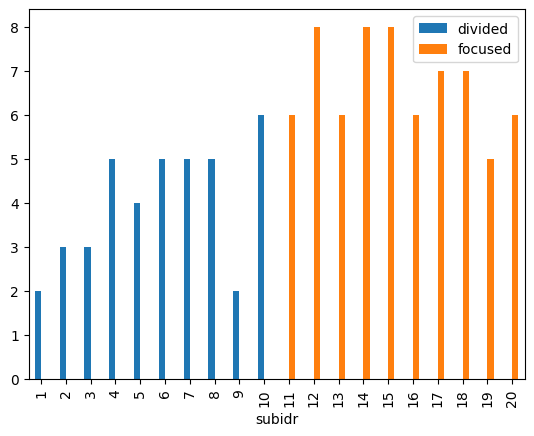

In [21]:
t = pt.Plotter()
k=(
    pt.sample_data['anagrams']
    # .drop(columns=['subidr'])
    
    

)
(
    t
    .data(k)
    .plot(x='subidr',y='num1',by='attnr',kind='bar')
)
t.fig

In [24]:
pt.sample_data['titanic']

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


## Titanic Plots

Common Titanic visualizations using a mosaic layout:
- **A** Survival rate by passenger class (bar)
- **B** Survival rate by sex (bar)
- **C** Survival rate by class and sex (grouped bar)
- **D** Passenger count by embarkation town and class (bar)
- **E** Age distribution by survival status (histogram)
- **F** Fare distribution by passenger class (KDE)


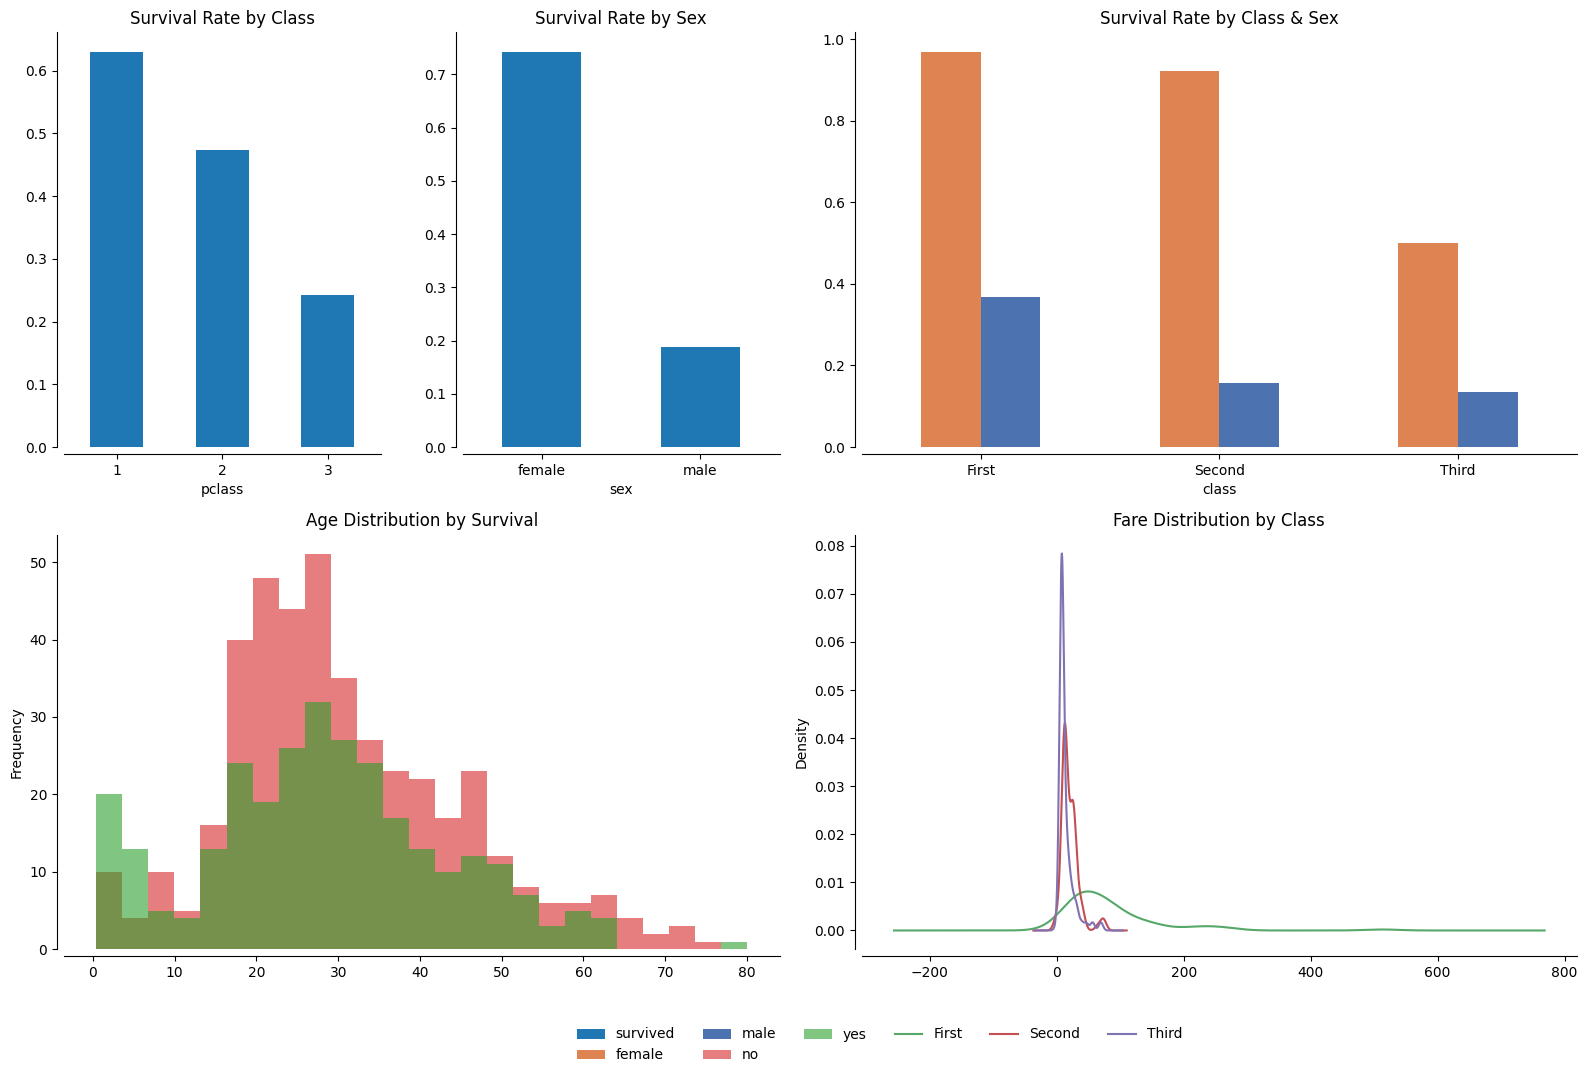

In [33]:
import pytae as pt

titanic = pt.sample_data['titanic']

# Color dicts keyed by the unique values of each 'by' column
color_sex   = {'male': '#4C72B0', 'female': '#DD8452'}
color_class = {'First': '#55A868', 'Second': '#C44E52', 'Third': '#8172B2'}
color_alive = {'yes': '#2ca02c', 'no': '#d62728'}

mosaic = """
ABCC
EEFF
"""

p = pt.Plotter(mosaic=mosaic, figsize=(16, 10))

(p
 # A: Survival rate by passenger class (plain bars, no color dict needed)
 .data(titanic)
 .plot(on='A', kind='bar', x='pclass', y='survived', aggfunc='mean',
       title='Survival Rate by Class' )

 # B: Survival rate by sex (plain bars, no by → no color dict)
 .data(titanic)
 .plot(on='B', kind='bar', x='sex', y='survived', aggfunc='mean',
       title='Survival Rate by Sex')

 # C: Survival rate by class and sex (grouped; by='sex' → color dict keyed by sex)
 .data(titanic)
 .plot(on='C', kind='bar', x='class', y='survived', by='sex', aggfunc='mean',
       color=color_sex, title='Survival Rate by Class & Sex',)



 # E: Age distribution split by survival status (hist; by='alive' → pivot cols are 'no'/'yes')
 .data(titanic)
 .plot(on='E', kind='hist', column='age', by='alive', bins=25, alpha=0.6,
       color=color_alive, title='Age Distribution by Survival')

 # F: Fare density by passenger class (kde; by='class' → pivot cols are class names)
 .data(titanic)
 .plot(on='F', kind='kde', column='fare', by='class',
       color=color_class, title='Fare Distribution by Class')

 .finalize(consolidate_legends=True, bbox_to_anchor=(0.75, -0.02), ncols=6)
)

p.fig
